<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>  

<center>
  <h2 style="color:#000000";>Séance 1 : Equations différentielles (1)</h2>
</center>

<center>
  <h2 style="color:#000000";> CORRECTION TP (version 2 avec programmation orientée objet)</h2>
</center>

## Parties A et B : Solution exacte + Euler explicite 

In [2]:
# Import des packages python
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

#### Classe "Param" : gestion plus modulaire des paramètres de simulation ($u_0$, $a$, $\Delta t$, $T$, ...)

In [3]:
class Param (object) : 
    ''' 
    Creation d'une classe Param dont la fonction principale (__init__) 
    spécifie tous les attributs des objets qui seront issus de cette classe Param.
    Ces attributs correspondent à l'ensemble des paramètres 
    à manipuler dans les simulations numériques.
    Les valeurs/instances données ici à ces paramètres sont des valeurs par défaut.
    '''
    def __init__ (self):
        # Paramètres de discrétisation temporelle
        ## Constantes
        self.u0 = 1.
        self.a = 1.
        self.T = 1.
        self.cfl = 0.
        self.dt = 0.
        self.n = 0
        ## Tableau des temps discrets
        self.t = np.zeros(self.n + 1)
        
        # Tableaux des solutions exacte et approchée
        self.solution_exacte = np.zeros(self.n + 1)
        self.solution_approchee = np.zeros(self.n + 1)
        
        # Fonctions python par défaut pour les simulations
        self.exact = sol_ex_lin
        self.function = linear
        self.schema = EulerExplicite

#### Traitement de la solution exacte

In [4]:
def tabtemps(param) :
    param.t = np.linspace(0, param.T, param.n + 1)

In [5]:
def sol_ex_lin(param) : 
    return np.exp(-param.a * param.t) * param.u0

In [6]:
def sol_ex_quad(param) :
    return param.u0 / (1. + param.u0 * param.a * param.t)

In [7]:
def calcul_solution_exacte(param) :
    param.solution_exacte = np.zeros(param.n + 1)
    param.solution_exacte = param.exact(param)

#### Implémentation du schéma d'Euler explicite

In [8]:
def linear(u, param) :
    return - param.a * u

In [9]:
def quadra(u, param) :
    return - param.a * u**2

In [10]:
def EulerExplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u[i+1] = u[i] + dt * param.function(u[i], param) 
    param.solution_approchee = u

In [11]:
def graphique(param) :
    fig, ax = plt.subplots(figsize=(7,4))
    ax.set_xlim(-0.01, param.T + 0.1)

    ax.plot(param.t, param.solution_exacte, color='red', label='solution exacte ')
    ax.plot(param.t, param.solution_approchee, color='black', marker='*', lw=0, label='solution approchee ')
    plt.xlabel('Temps')
    plt.ylabel('Solution u(t)')
    ax.grid(True)
    ax.legend(loc='best')

    plt.draw()

#### Résultats numériques pour Euler explicite, cas linéaire :

nombre pas de temps :  50


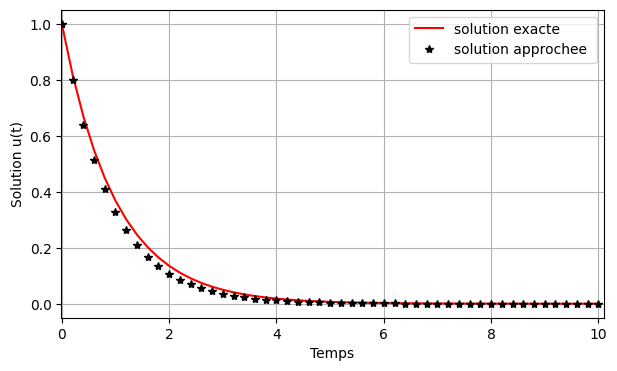

In [12]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# On spécifie des valeurs pour les attributs
# de l'objet "param" différentes de celles définies par défaut :
param.T = 10.
param.cfl = 0.1
param.dt = 2. * param.cfl / param.a
param.n = int(param.T / param.dt)
print("nombre pas de temps : ", param.n)

# Appel des fonctions python "tabtemps", "calcul_solution_exacte" et "EulerExplicite" 
# en passant comme argument l'objet "param"
tabtemps(param) # --> mise à jour de l'attribut param.t
calcul_solution_exacte(param) # --> mise à jour de l'attribut param.solution_exacte
EulerExplicite(param) # --> mise à jour de l'attribut param.solution_approchee

# Appel de la fonction "graphique" en passant comme argument l'objet "param"
graphique(param)

#### Résultats numériques pour Euler explicite, cas non linéaire (quadratique) :

nombre pas de temps :  40


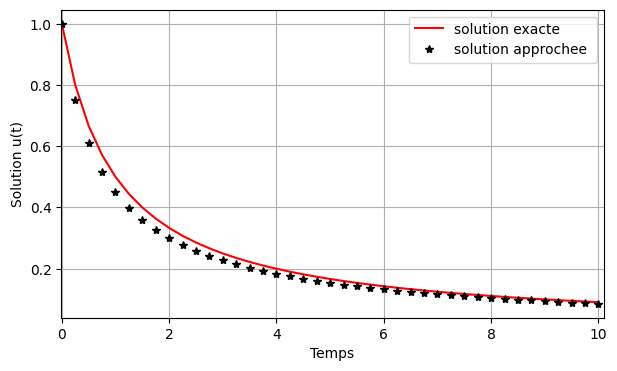

In [13]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.T = 10.
param.cfl = 0.125
param.dt = 2. * param.cfl / param.a
param.n = int(param.T / param.dt)
print("nombre pas de temps : ", param.n)
param.function = quadra # on souhaite maintenant une fonction quadratique (et non plus lineaire comme par défaut)
param.exact = sol_ex_quad # on change donc aussi la valeur de la solution exacte

# Appel des fonctions python 
tabtemps(param)
calcul_solution_exacte(param)
EulerExplicite(param) 

# Appel de la fonction "graphique"
graphique(param)

## Partie C : Euler implicite

Le but de cette partie est maintenant d'implémenter la méthode d'Euler implicite.  
On a vu dans la partie cours que le calcul de l'itéré $u^{n+1}$ par la méthode d'Euler implicite reposait en fait sur la résolution de l'équation $(6)$ (potentiellement non linéaire si $f$ est non linéaire) :

$$(6) \quad \underbrace{\dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1})}_{g(u^{n+1})} = 0$$

**7)** Implémenter une fonction python `fonct_implicite` qui à partir d'une fonction mathématique $f$ donnée et des valeurs des itérés $u^{n+1}$ et $u^{n}$, renvoie la valeur $ \ g(u^{n+1}) = \dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1}) \ $ (membre de gauche de la relation $(6)$).

In [14]:
def fonct_implicite(u_np1, u_n):
    g_u = param.function(u_np1, param) - (u_np1 - u_n) / param.dt
    return g_u

**8)** Compléter la fonction python `EulerImplicite` ci-dessous. A chaque itération de votre algorithme, le calcul de l'itéré $u^{n+1}$ se fera en résolvant l'équation $(6)$. Pour cela on fera appel à une fonction existante de la librairie `scipy` (Scientific Python), à savoir la fonction `scipy.optimize.fsolve()`.

$\rightarrow$ Comment utiliser la fonction `scipy.optimize.fsolve()` ?
* arguments d'entrée : dans notre cas la fonction `fsolve` aura besoin de 3 arguments distints (à donner dans cet ordre) :
    * 1 fonction : la fonction python implémentant la fonction mathématique $g$ (ici, ce sera `fonct_implicite`)
    * 1 valeur : la valeur avec laquelle la fonction `fsolve` doit démarrer son algorithme : on pourra mettre $u^{n}$, l'itéré calculé à l'itération précédente
    * 1 valeur :  la valeur de l'itéré calculé à l'itération précédente c'est à dire $u^{n}$. 
* sorties :
    * la fonction `fsolve` nous donnera 1 unique sortie : il s'agit de la solution $u^{n+1}$ 
    
Pour plus de détails sur la fonction `fsolve`, voir la [documentation officielle](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.optimize.fsolve.html)

In [15]:
def EulerImplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    u = np.zeros(n+1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_implicite, u[i], u[i])
    param.solution_approchee = u

**9)** Reprendre la question **6)** de la partie B pour le cas de la méthode d'Euler implicite cette fois-ci.

#### Résultats numériques pour Euler implicite, cas linéaire (`f_linear`) :

nombre pas de temps :  40


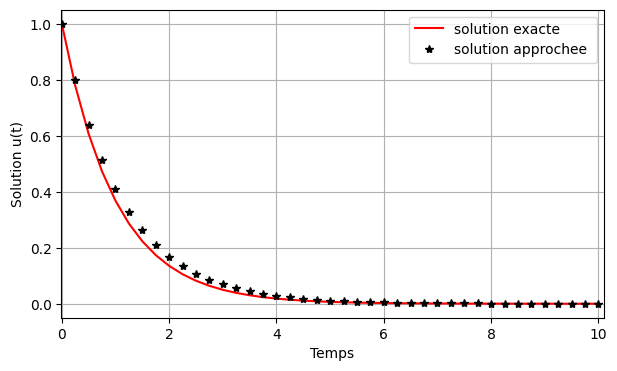

In [16]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.schema = EulerImplicite # on souhaite maintenant un schema d'Euler implicite
param.T = 10.
param.cfl = 0.125
param.dt = 2. * param.cfl / param.a
param.n = int(param.T / param.dt)
print("nombre pas de temps : ", param.n)

# Appel des fonctions python
tabtemps(param)
calcul_solution_exacte(param)
EulerImplicite(param)

# Appel de la fonction "graphique" en passant comme argument l'objet "param"
graphique(param)

#### Résultats numériques pour Euler implicite, cas quadratique (`f_quadra`) :

nombre pas de temps :  40


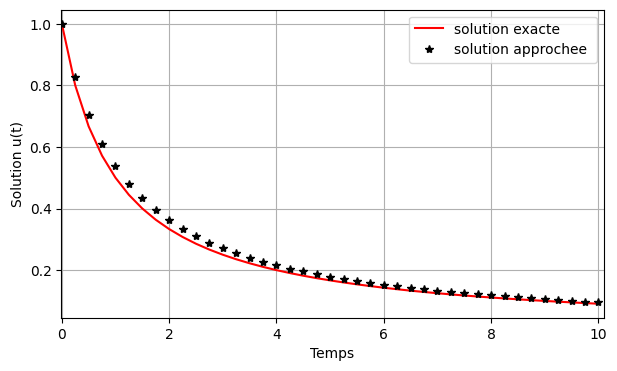

In [17]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.schema = EulerImplicite # on souhaite maintenant un schema d'Euler implicite
param.T = 10.
param.cfl = 0.125
param.dt = 2. * param.cfl / param.a
param.n = int(param.T/param.dt)
print("nombre pas de temps : ", param.n)
param.function = quadra
param.exact = sol_ex_quad

# Appel des fonctions python
tabtemps(param)
calcul_solution_exacte(param)
EulerImplicite(param)

# Appel de la fonction "graphique" en passant comme argument l'objet "param"
graphique(param)